In [1]:
# Imorting necessary libraries
import tensorflow as tf 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers

In [2]:
# Loading the dataset
data = tf.keras.datasets.fashion_mnist.load_data()
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
# Splitting the dataset into training and testing sets
(train_images, train_labels), (test_images, test_labels) = data


In [4]:
print("Train Images:", train_images.shape)
print("Train Labels:", train_labels.shape)
print("Test Images:", test_images.shape)
print("Test Labels:", test_labels.shape)

Train Images: (60000, 28, 28)
Train Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


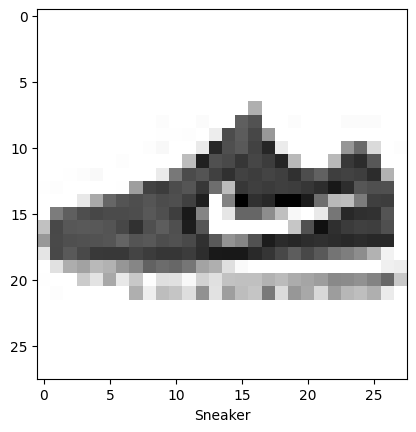

In [5]:
# Displaying a random image from the training set
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [6]:
# Normalizing the pixel values to be between 0 and 1
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

In [7]:
# To increase the diversity of the training data and help prevent overfitting, we can apply data augmentation techniques. 
# This will create variations of the existing images, such as rotations, zooms, and shifts, which can help the model generalize better to unseen data.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1), 
    tf.keras.layers.RandomZoom(0.2),
])

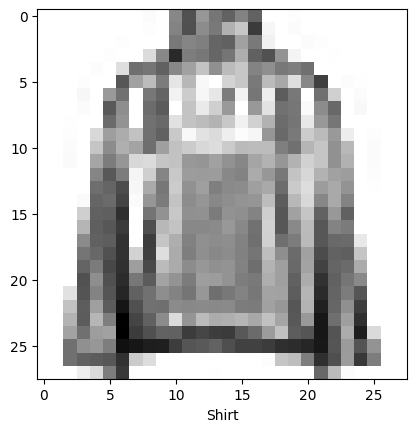

In [8]:
# Displaying a random image from the training set after normalization 
rndm = np.random.randint(0, len(train_images))
plt.xlabel(classes[train_labels[rndm]])
plt.imshow(train_images[rndm], cmap=plt.cm.binary)

In [9]:
# Displaying the pixel values of the random image
print("pixel_value:")
for row in train_images[rndm]:
    for pixel in row:
        print("{:0.3f}".format(pixel), end=" ")
    print()

pixel_value:
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.016 0.000 0.471 0.682 0.408 0.537 0.612 0.486 0.612 0.000 0.000 0.008 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.008 0.000 0.482 0.686 0.451 0.525 0.306 0.220 0.769 0.035 0.000 0.016 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.000 0.008 0.000 0.000 0.000 0.529 0.478 0.502 0.604 0.620 0.369 0.525 0.055 0.000 0.000 0.016 0.008 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.000 0.008 0.000 0.000 0.137 0.467 0.835 0.510 0.533 0.600 0.541 0.318 0.616 0.678 0.420 0.043 0.000 0.000 0.004 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.000 0.012 0.000 0.129 0.565 0.541 0.616 0.467 0.369 0.239 0.435 0.267 0.220 0.486 0.439 0.529 0.506 0.561 0.000 0.000 0.000 0.000 0.000 0.000 0.000 
0.000 0.000 0.000 0.008 0.000 0.000 0.663 0.369 0.263 0.514 0.102 0.282 0.027 0.000 0.169 0.220 0.525 0.267 0.341 0.129 0.471 0.753 0.000 0.01

In [10]:
# Reshape images to (28, 28, 1) to add a channel dimension for the CNN
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
# Creating CNN model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3),activation='relu', padding='same'),
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu', padding='same'),
    #tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,978 (562.41 KB)

 Trainable params: 143,978 (562.41 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Create datasets with augmentation
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(32).prefetch(tf.data.AUTOTUNE)

In [13]:
# Training the CNN model
model.fit(train_images, train_labels, epochs=50, validation_data=(test_images, test_labels))
#model.fit(train_ds, epochs=30, validation_data=test_ds)

Epoch 1/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7045 - loss: 0.7826 - val_accuracy: 0.8164 - val_loss: 0.5015
Epoch 2/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.7999 - loss: 0.5384 - val_accuracy: 0.8437 - val_loss: 0.4290
Epoch 3/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8254 - loss: 0.4712 - val_accuracy: 0.8486 - val_loss: 0.4346
Epoch 4/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8404 - loss: 0.4307 - val_accuracy: 0.8664 - val_loss: 0.3747
Epoch 5/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8508 - loss: 0.4063 - val_accuracy: 0.8677 - val_loss: 0.3591
Epoch 6/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8604 - loss: 0.3833 - val_accuracy: 0.8704 - val_loss: 0.3579
Epoch 7/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8614 - loss: 0.3729 - val_accuracy: 0.8673 - val_loss: 0.3652
Epoch 8/60
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8665 -

KeyboardInterrupt: 

In [ ]:
# Evaluating the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)   

313/313 - 1s - 2ms/step - accuracy: 0.8920 - loss: 0.6345
Test Loss: 0.6344940662384033
Test Accuracy: 0.8920000195503235


In [ ]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
i = np.random.randint(0, len(test_images))
print("Predicted Label:", np.argmax(predictions[i]))
print("Actual Label:", test_labels[i])

Predicted Label: 0
Actual Label: 0


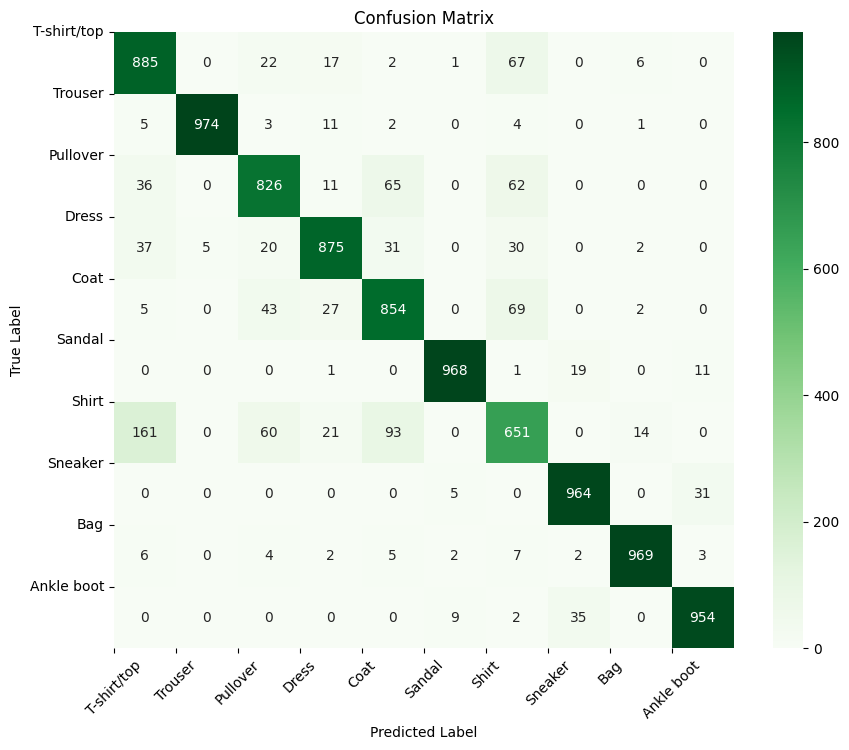

In [ ]:
# Confusion Matrix to better understand the model's performance across different classes
cm = confusion_matrix(test_labels, np.argmax(predictions, axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45)
plt.yticks(np.arange(len(classes)), classes, rotation=0)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Saving the trained model for future use
model.save("fashion_mnist_model.keras")